# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
!pip install Sastrawi
import pandas as pd
import numpy as np
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import StandardScaler

# Download resource NLTK yang dibutuhkan
nltk.download('punkt')
nltk.download('stopwords')

from sklearn.preprocessing import StandardScaler

# Inisialisasi Stemmer
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

# Inisialisasi Stopword Remover Sastrawi
stop_factory = StopWordRemoverFactory()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:

# --- Konfigurasi ---
root_dir = 'Eksperimen_SML_Yoga-pratama'
raw_subfolder = 'indonesian_crime_tweets_simulated_labeled_raw'
file_name = 'indonesian_crime_tweets_simulated_labeled.csv'

sub_folders = [
    raw_subfolder,
    'preprocessing',
    'preprocessing/indonesian_crime_tweets_simulated_labeled_preprocessed'
]

# 1. Buat Struktur Folder
os.makedirs(root_dir, exist_ok=True)
for folder in sub_folders:
    os.makedirs(os.path.join(root_dir, folder), exist_ok=True)

# 2. Lokasi Pencarian
source_path = file_name
destination_path = os.path.join(root_dir, raw_subfolder, file_name)

# 3. Pindahkan File Jika Ada
if os.path.exists(source_path):
    shutil.move(source_path, destination_path)
    print(f"[OK] File ditemukan di luar dan dipindahkan ke: {destination_path}")

# 4. Mencoba Membaca File
if os.path.exists(destination_path):
    try:
        df = pd.read_csv(destination_path, encoding='utf-8')
        print("[*] SUCCESS: Dataset berhasil dimuat!")

        # --- ANALISIS DATA (Hanya jalan jika df ada) ---
        print("\n--- 5 Baris Pertama ---")
        display(df.head())

        print("\n--- Informasi Dataset ---")
        df.info()

        print("\n--- Jumlah Data Kosong per Kolom ---")
        print(df.isnull().sum())

        if 'label' in df.columns:
            print("\n--- Distribusi Kategori ---")
            print(df['label'].value_counts())

    except Exception as e:
        print(f"[!] Terjadi kesalahan saat membaca file: {e}")
else:
    print(f"[!] STOP: File '{file_name}' BELUM ADA di folder '{raw_subfolder}'.")
    print(f"    Saran: Silakan upload file tersebut sekarang ke panel kiri Colab.")

[OK] File ditemukan di luar dan dipindahkan ke: Eksperimen_SML_Yoga-pratama/indonesian_crime_tweets_simulated_labeled_raw/indonesian_crime_tweets_simulated_labeled.csv
[*] SUCCESS: Dataset berhasil dimuat!

--- 5 Baris Pertama ---


,Unnamed: 0,text,created_at,user_followers,user_friends,retweet_count,favorite_count,processed_text,label
0,0,Teater menjadi sorotan media.,2024-03-05 22:00:06,1275,1452,128,96,teater sorot media,1
1,1,Pencemaran nama baik polisi masih memburu pela...,2024-06-21 23:34:24,3707,3416,73,239,cemar nama polisi buru laku,0
2,2,Pemalsuan tersangka akan segera diadili.,2024-05-09 13:56:44,7276,334,23,255,palsu sangka adil,0
3,3,Energi terbarukan menyediakan fasilitas baru.,2024-06-24 09:12:59,7424,4789,454,66,energi baru sedia fasilitas,1
4,4,Penganiayaan tersangka mencoba melarikan diri.,2024-01-21 10:44:27,2956,1403,346,225,aniaya sangka coba lari,0



--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      10000 non-null  int64 
 1   text            10000 non-null  object
 2   created_at      10000 non-null  object
 3   user_followers  10000 non-null  int64 
 4   user_friends    10000 non-null  int64 
 5   retweet_count   10000 non-null  int64 
 6   favorite_count  10000 non-null  int64 
 7   processed_text  10000 non-null  object
 8   label           10000 non-null  int64 
dtypes: int64(6), object(3)
memory usage: 703.3+ KB

--- Jumlah Data Kosong per Kolom ---
Unnamed: 0        0
text              0
created_at        0
user_followers    0
user_friends      0
retweet_count     0
favorite_count    0
processed_text    0
label             0
dtype: int64

--- Distribusi Kategori ---
label
0    3824
2    3226
1    2950
Name: count, dtype: int64


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

/tmp/ipykernel_11738/761535609.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


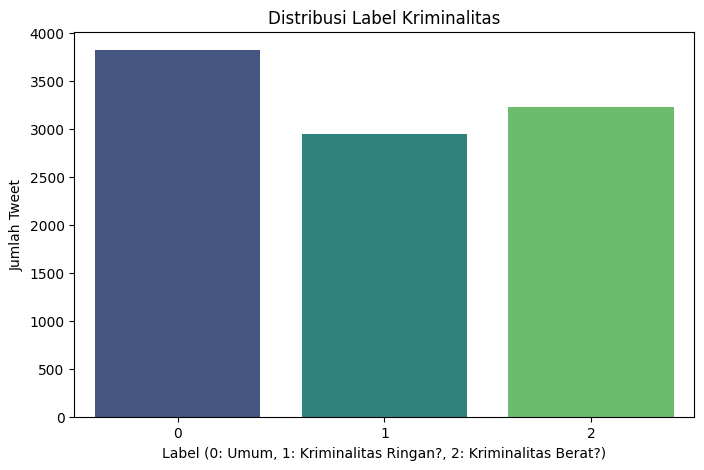

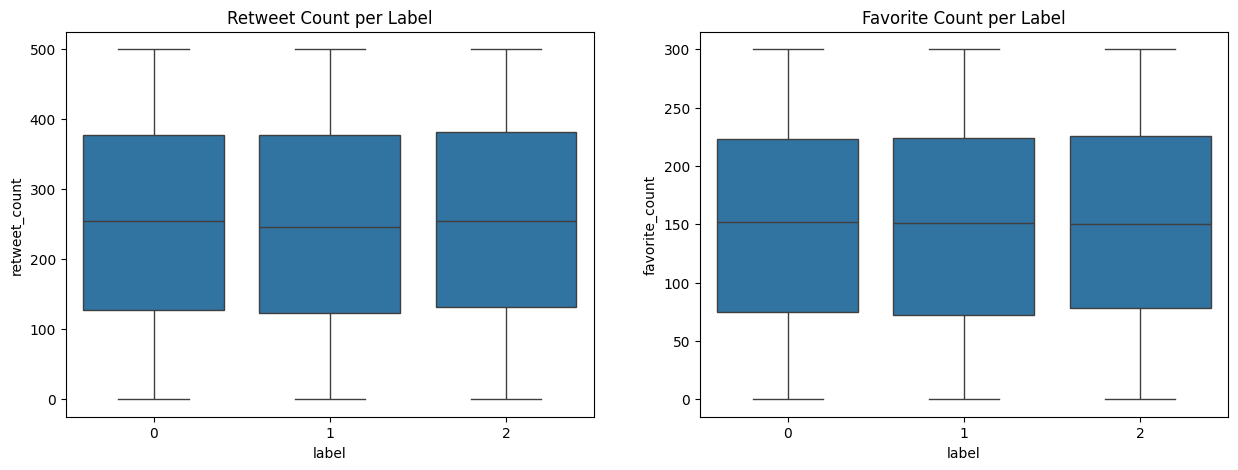

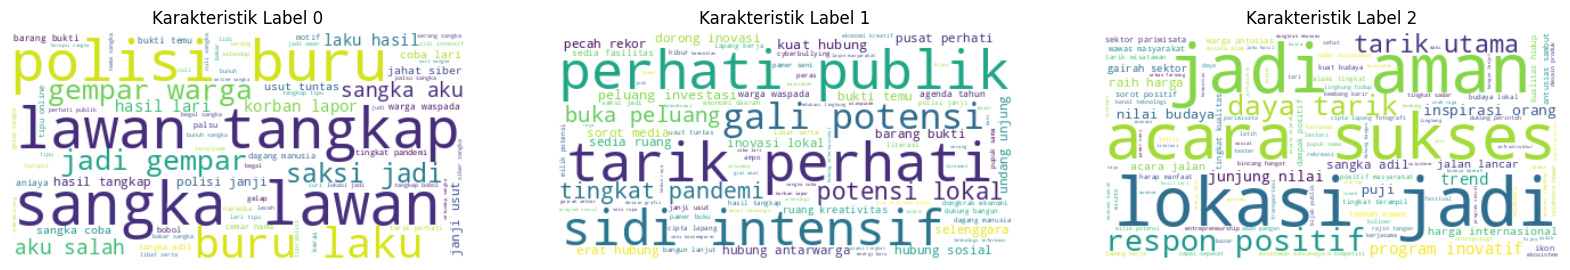

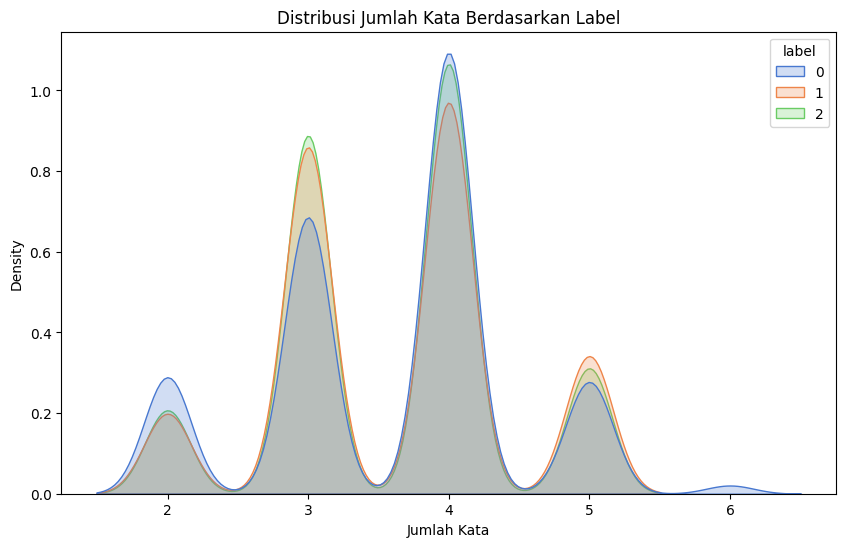

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribusi Label Kriminalitas')
plt.xlabel('Label (0: Umum, 1: Kriminalitas Ringan?, 2: Kriminalitas Berat?)')
plt.ylabel('Jumlah Tweet')
plt.show()

plt.figure(figsize=(15, 5))

# Plot Retweet Count per Label
plt.subplot(1, 2, 1)
sns.boxplot(x='label', y='retweet_count', data=df)
plt.title('Retweet Count per Label')

# Plot Favorite Count per Label
plt.subplot(1, 2, 2)
sns.boxplot(x='label', y='favorite_count', data=df)
plt.title('Favorite Count per Label')

plt.show()

from wordcloud import WordCloud

def plot_wordcloud(label, title):
    text = " ".join(df[df['label'] == label]['processed_text'].astype(str))
    wordcloud = WordCloud(width=400, height=200, background_color='white').generate(text)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(20, 10))

plt.subplot(1, 3, 1)
plot_wordcloud(0, 'Karakteristik Label 0')

plt.subplot(1, 3, 2)
plot_wordcloud(1, 'Karakteristik Label 1')

plt.subplot(1, 3, 3)
plot_wordcloud(2, 'Karakteristik Label 2')

plt.show()

df['word_count'] = df['processed_text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='word_count', hue='label', fill=True, common_norm=False, palette='muted')
plt.title('Distribusi Jumlah Kata Berdasarkan Label')
plt.xlabel('Jumlah Kata')
plt.show()



# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
# --- 1. INISIALISASI SASTRAWI & CUSTOM STOPWORDS ---
factory_sw = StopWordRemoverFactory()
# Ambil stop words standar dan hapus kata yang mengandung emosi/negasi penting
stop_words = set(factory_sw.get_stop_words())
removable_stop_words = {'tidak', 'kurang', 'lama', 'lambat', 'sulit', 'sekali', 'masalah', 'salah'}
for word in removable_stop_words:
    stop_words.discard(word)

# Tambahkan kata sampah umum media sosial (disesuaikan dari konteks ulasan ke tweet umum)
additional_stop_words = {
    'yg', 'dg', 'rt', 'dgn', 'ny', 'd', 'kalo', 'amp', 'biar', 'bikin', 'nya',
    'ini', 'itu', 'saya', 'dan', 'di', 'si', 'ya', 'aja', 'ke', 'ka', 'pun',
    'halo', 'admin', 'min', 'mohon', 'woy', 'sih', 'loh', 'user', 'url'
}
stop_words.update(additional_stop_words)

# --- 2. UPDATE SLANG DICT (Konteks Kriminalitas + Umum) ---
slangwords = {
    "abis": "habis", "masi": "masih", "bgt": "sekali", "gak": "tidak",
    "ga": "tidak", "nggak": "tidak", "tdk": "tidak", "gk": "tidak",
    "banget": "sekali", "udah": "sudah", "sdh": "sudah", "ribet": "sulit",
    "susah": "sulit", "eror": "bug", "gajelas": "tidak jelas", "maling": "curi",
    "pake": "pakai", "tanda": "bukti", "tkp": "lokasi"
}

# --- 3. FUNGSI PIPELINE PREPROCESSING ---

def cleaning_pro(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', text) # Mentions
    text = re.sub(r'#[A-Za-z0-9_]+', '', text) # Hashtags
    text = re.sub(r'RT[\s]', '', text)          # RT
    text = re.sub(r"http\S+", '', text)         # Links
    text = re.sub(r'[0-9]+', '', text)          # Numbers
    text = text.translate(str.maketrans('', '', string.punctuation)) # Punctuation
    text = text.strip()
    return text

def fix_slang(text):
    words = text.split()
    fixed = [slangwords[w.lower()] if w.lower() in slangwords else w for w in words]
    return ' '.join(fixed)

def filter_words(text):
    tokens = text.lower().split()
    filtered = [w for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(filtered)

# --- 4. EKSEKUSI PADA DATAFRAME ---

# Asumsikan df sudah dimuat dari CSV sumber
df_clean = df.copy()

print("Memulai Preprocessing...")

# Langkah-langkah berurutan
df_clean['processed_text'] = df_clean['text'].apply(cleaning_pro)
df_clean['processed_text'] = df_clean['processed_text'].apply(fix_slang)
df_clean['processed_text'] = df_clean['processed_text'].apply(filter_words)


# --- 5. SCALING FITUR NUMERIK ---
scaler = StandardScaler()
num_cols = ['user_followers', 'user_friends', 'retweet_count', 'favorite_count']
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

# --- 6. SIMPAN HASIL ---
# Menghapus baris yang mungkin kosong setelah filtering
df_clean = df_clean[df_clean['processed_text'].str.strip() != ""]

# Menentukan Path Output
output_folder = os.path.join(root_dir, 'preprocessing', 'indonesian_crime_tweets_simulated_labeled_preprocessed')

# Buat foldernya jika belum ada (safety check)
os.makedirs(output_folder, exist_ok=True)

output_name = 'indonesian_crime_tweets_preprocessed.csv'
output_path = os.path.join(output_folder, output_name)

# 3. Eksekusi Simpan
df_clean.to_csv(output_path, index=False)

print(f"Data tersimpan di {output_path}. Total baris: {len(df_clean)}")
display(df_clean[['processed_text', 'label']].head())

Memulai Preprocessing...
Data tersimpan di Eksperimen_SML_Yoga-pratama/preprocessing/indonesian_crime_tweets_simulated_labeled_preprocessed/indonesian_crime_tweets_preprocessed.csv. Total baris: 10000


,processed_text,label
0,teater menjadi sorotan media,1
1,pencemaran nama baik polisi memburu pelaku,0
2,pemalsuan tersangka segera diadili,0
3,energi terbarukan menyediakan fasilitas baru,1
4,penganiayaan tersangka mencoba melarikan diri,0


# **6. Automate Preprocessing**

In [ ]:
import os

# Definisikan isi konten skrip Python dengan r""" (Raw String)
# Ini untuk menghindari SyntaxWarning terkait invalid escape sequence \s
automate_script_content = r"""import pandas as pd
import numpy as np
import re
import string
import os
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.preprocessing import StandardScaler

def main():
    # --- 1. KONFIGURASI PATH ---
    # Menggunakan nama folder yang konsisten (Yoga-pratama)
    ROOT_DIR = 'Eksperimen_SML_Yoga-pratama'
    INPUT_DIR = os.path.join(ROOT_DIR, 'indonesian_crime_tweets_simulated_labeled_raw')
    OUTPUT_DIR = os.path.join(ROOT_DIR, 'preprocessing', 'indonesian_crime_tweets_simulated_labeled_preprocessed')

    input_file = os.path.join(INPUT_DIR, 'indonesian_crime_tweets_simulated_labeled.csv')
    output_file = os.path.join(OUTPUT_DIR, 'indonesian_crime_tweets_preprocessed.csv')

    # Memastikan folder output tersedia
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # --- 2. LOAD DATA ---
    try:
        if not os.path.exists(input_file):
            print(f"[!] Error: File {input_file} tidak ditemukan.")
            return

        df = pd.read_csv(input_file)
        print(f"[*] Berhasil memuat: {input_file}")
    except Exception as e:
        print(f"[!] Error saat memuat file: {e}")
        return

    # --- 3. SETUP STOPWORDS & SLANG ---
    factory_sw = StopWordRemoverFactory()
    stop_words = set(factory_sw.get_stop_words())

    # Kata kunci yang harus dipertahankan
    removable = {'tidak', 'kurang', 'lama', 'lambat', 'sulit', 'sekali', 'masalah', 'salah'}
    for w in removable:
        stop_words.discard(w)

    additional_sw = {
        'yg', 'dg', 'rt', 'dgn', 'ny', 'd', 'kalo', 'amp', 'biar', 'bikin', 'nya',
        'ini', 'itu', 'saya', 'dan', 'di', 'si', 'ya', 'aja', 'ke', 'ka', 'pun',
        'halo', 'admin', 'min', 'mohon', 'woy', 'sih', 'loh', 'user', 'url'
    }
    stop_words.update(additional_sw)

    slang_dict = {
        "abis": "habis", "masi": "masih", "bgt": "sekali", "gak": "tidak",
        "ga": "tidak", "nggak": "tidak", "tdk": "tidak", "gk": "tidak",
        "banget": "sekali", "udah": "sudah", "sdh": "sudah", "pake": "pakai",
        "maling": "curi", "tkp": "lokasi"
    }

    # --- 4. PIPELINE FUNGSI ---
    def clean_process(text):
        # Basic Cleaning
        text = re.sub(r'@[A-Za-z0-9_]+|#|RT[\s]|http\S+|[0-9]+', '', str(text))
        text = text.translate(str.maketrans('', '', string.punctuation)).lower().strip()

        # Slang Handling & Stopwords
        words = text.split()
        fixed_words = []
        for w in words:
            word = slang_dict[w] if w in slang_dict else w
            if word not in stop_words and len(word) > 2:
                fixed_words.append(word)

        return ' '.join(fixed_words)

    # --- 5. EKSEKUSI ---
    print("[*] Memulai pembersihan teks...")
    if 'text' in df.columns:
        df['processed_text'] = df['text'].apply(clean_process)
        # Hapus baris kosong setelah cleaning
        df = df[df['processed_text'].str.strip() != ""]
    else:
        print("[!] Error: Kolom 'text' tidak ditemukan dalam dataset.")
        return

    print("[*] Melakukan standarisasi fitur numerik...")
    num_cols = ['user_followers', 'user_friends', 'retweet_count', 'favorite_count']
    # Pastikan kolom numerik ada sebelum scaling
    existing_num_cols = [col for col in num_cols if col in df.columns]

    if existing_num_cols:
        scaler = StandardScaler()
        df[existing_num_cols] = scaler.fit_transform(df[existing_num_cols])

    # --- 6. SIMPAN HASIL ---
    df.to_csv(output_file, index=False)
    print("-" * 30)
    print(f"[SUCCESS] File otomatis tersimpan di: {output_file}")
    print(f"[*] Total data akhir: {len(df)} baris")
    print("-" * 30)

if __name__ == "__main__":
    main()
"""

# Tentukan lokasi penyimpanan file .py
file_path = os.path.join('Eksperimen_SML_Yoga-pratama', 'preprocessing', 'automate_Yoga-pratama.py')

# Pastikan folder tujuan ada sebelum menulis file
os.makedirs(os.path.dirname(file_path), exist_ok=True)

# Tulis file
with open(file_path, 'w') as f:
    f.write(automate_script_content)

print(f"[*] File otomasi berhasil dibuat tanpa Warning di: {file_path}")

[*] File otomasi berhasil dibuat tanpa Warning di: Eksperimen_SML_Yoga-pratama/preprocessing/automate_Yoga-pratama.py


# **7. Workflow**

In [ ]:
import os

# --- PENYESUAIAN STRUKTUR SUBMISSION ---

# 1. Gunakan nama folder sesuai instruksi: .workflow
workflow_dir = os.path.join('Eksperimen_SML_Yoga-pratama','.workflow')
os.makedirs(workflow_dir, exist_ok=True)

# 2. Konten YAML (disesuaikan path-nya ke 'automate_Yoga-pratama.py')
yaml_content = """name: Preprocessing Pipeline

on:
  push:
    branches: [ main ]

jobs:
  build:
    runs-on: ubuntu-latest
    steps:
    - name: Checkout Repository
      uses: actions/checkout@v3

    - name: Set up Python 3.9
      uses: actions/setup-python@v4
      with:
        python-version: '3.9'

    - name: Install Dependencies
      run: |
        pip install pandas numpy scikit-learn Sastrawi nltk

    - name: Run Automation Preprocessing
      run: |
        # Menjalankan automate_Nama-siswa.py di dalam folder preprocessing
        python "preprocessing/automate_Yoga-pratama.py"
"""

# 3. Simpan file YAML ke dalam folder .workflow
workflow_file_path = os.path.join(workflow_dir, 'preprocessing_pipeline.yml')

with open(workflow_file_path, 'w') as f:
    f.write(yaml_content)

# --- VERIFIKASI AKHIR STRUKTUR ---
print("--- VERIFIKASI STRUKTUR SUBMISSION ---")
print(f"1. Folder Workflow: {os.path.exists('.workflow')}")
print(f"2. Folder Raw     : {os.path.exists(os.path.join(root_dir, 'indonesian_crime_tweets_simulated_labeled_raw'))}")
print(f"3. Folder Prepro  : {os.path.exists(os.path.join(root_dir, 'preprocessing'))}")
print("-" * 40)
print(f"[*] Berhasil dibuat: {workflow_file_path}")

--- VERIFIKASI STRUKTUR SUBMISSION ---
1. Folder Workflow: False
2. Folder Raw     : True
3. Folder Prepro  : True
----------------------------------------
[*] Berhasil dibuat: Eksperimen_SML_Yoga-pratama/.workflow/preprocessing_pipeline.yml
